In [35]:
import pandas as pd
import numpy as np
data = pd.read_csv(r"C:\Users\ASUS\Desktop\CFBPredic\src\data.csv")
data = data.set_index("date")
data.index = pd.to_datetime(data.index)
# ===============================
# 0. PARTIMOS DEL DATAFRAME BASE
# ===============================

# Supongo que ya tienes data_ts con índice fecha y las 12 columnas de índices
# Si tu DF base se llama distinto, cámbialo aquí:
df = data.copy().sort_index()

# Opcional: asegurar que todas las columnas son numéricas
df = df.astype(float)

# Lista explícita de columnas de nivel (por claridad)
level_cols = [
    "ipc_alimentos_index",
    "aceites_y_grasas",
    "aguas_minerales_refrescos_jugos_de_frutas_y_de_legumbres",
    "azucar_mermelada_miel_chocolate_y_dulces_de_azucar",
    "cafe_te_y_cacao",
    "carne",
    "frutas",
    "leche_queso_y_huevos",
    "legumbres_hortalizas",
    "pan_y_cereales",
    "pescado",
    "productos_alimenticios_n.e.p.",
]

# Nos aseguramos de que existen todas (por si has cambiado algún nombre)
missing = [c for c in level_cols if c not in df.columns]
if missing:
    print("OJO: faltan estas columnas en df:", missing)


# =======================================
# 1. VARIACIÓN MENSUAL (%) DE TODAS LAS SERIES
# =======================================

# Objetivo económico: trabajar con INFLACIÓN mensual, no solo con niveles
for col in level_cols:
    df[col + "_var"] = df[col].pct_change() * 100.0   # variación mensual en %

# En particular, la que nos interesa como objetivo:
df["ipc_var_mensual"] = df["ipc_alimentos_index"].pct_change() * 100.0   # redundante pero claro


# =======================================
# 2. VARIABLE OBJETIVO: INFLACIÓN ALIMENTARIA FUTURA (t + 1)
# =======================================

# Queremos predecir la variación mensual del IPC–Alimentos del mes siguiente
# y_t = ipc_var_mensual en t + 1

df["y_ipc_var_lead1"] = df["ipc_var_mensual"].shift(-1)

# Esta será nuestra Y en los modelos de forecasting & explicación


# =======================================
# 3. LAGS (REZAGOS) DE IPC–ALIMENTOS Y DE PRODUCTOS
# =======================================

# Max lag que quieres considerar (puedes ajustar a 3, 6, 12)
MAX_LAG = 12

# 3.1 Lags del nivel del IPC–Alimentos (por si usas modelos en niveles)
for lag in range(1, MAX_LAG + 1):
    df[f"ipc_index_lag{lag}"] = df["ipc_alimentos_index"].shift(lag)

# 3.2 Lags de la variación mensual del IPC–Alimentos
for lag in range(1, MAX_LAG + 1):
    df[f"ipc_var_lag{lag}"] = df["ipc_var_mensual"].shift(lag)

# 3.3 Lags de la variación mensual de cada producto (solo lag 1 para no explotar dimensionalidad)
for col in level_cols:
    var_col = col + "_var"
    df[var_col + "_lag1"] = df[var_col].shift(1)


# =======================================
# 4. VARIABLES ESTACIONALES (MES, DUMMIES)
# =======================================

df["month"] = df.index.month
df["year"] = df.index.year

# Dummies mensuales (efectos fijos por mes)
month_dummies = pd.get_dummies(df["month"], prefix="month", drop_first=False)
df = pd.concat([df, month_dummies], axis=1)


# =======================================
# 5. VENTANAS MÓVILES (ROLLING WINDOWS) DEL IPC
# =======================================

# Promedio móvil de la inflación mensual de alimentos (3 y 6 meses)
df["ipc_var_ma3"] = df["ipc_var_mensual"].rolling(window=3).mean()
df["ipc_var_ma6"] = df["ipc_var_mensual"].rolling(window=6).mean()

# Volatilidad móvil (desv. estándar) de la inflación en los últimos 6 meses
df["ipc_var_std6"] = df["ipc_var_mensual"].rolling(window=6).std()


# =======================================
# 6. CONSTRUCCIÓN DEL DATASET FINAL PARA MODELADO
# =======================================

# 6.1 Columnas que vamos a usar como FEATURES (X)
#     – evitamos duplicar columnas obvias

feature_cols = []

# a) Variaciones mensuales actuales de los productos (información contemporánea)
feature_cols += [col + "_var" for col in level_cols]   # pan_var, carne_var, etc.

# b) Lags de la inflación de alimentos
feature_cols += [f"ipc_var_lag{lag}" for lag in range(1, MAX_LAG + 1)]

# c) Lags de variaciones de productos (solo lag1 para no explotar dimensión)
feature_cols += [col + "_var_lag1" for col in level_cols]

# d) Rolling features del IPC
feature_cols += ["ipc_var_ma3", "ipc_var_ma6", "ipc_var_std6"]

# e) Dummies de mes (capturan estacionalidad)
feature_cols += [c for c in df.columns if c.startswith("month_")]

# 6.2 Variable objetivo
target_col = "y_ipc_var_lead1"

# 6.3 Armamos el DataFrame final
model_df = df[[target_col] + feature_cols].copy()

# Eliminamos filas con NaN (por lags, rolling y lead)
model_df = model_df.dropna().copy()

print("Shape final del dataset para modelos:", model_df.shape)
print("Rango de fechas:", model_df.index.min(), "→", model_df.index.max())

# Vista rápida
model_df.head()


Shape final del dataset para modelos: (224, 52)
Rango de fechas: 2007-02-01 00:00:00 → 2025-09-01 00:00:00


,y_ipc_var_lead1,ipc_alimentos_index_var,aceites_y_grasas_var,aguas_minerales_refrescos_jugos_de_frutas_y_de_legumbres_var,azucar_mermelada_miel_chocolate_y_dulces_de_azucar_var,cafe_te_y_cacao_var,carne_var,frutas_var,leche_queso_y_huevos_var,legumbres_hortalizas_var,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,,,,,,,,,,
2007-02-01,0.364155,0.095087,-0.074129,0.141755,-0.106270,-0.583090,0.167990,3.853831,-0.716739,-2.228009,...,False,False,False,False,False,False,False,False,False,False
2007-03-01,-0.299732,0.364155,1.038576,0.471846,-0.987842,0.733138,-0.853789,0.310467,0.481275,-1.598106,...,True,False,False,False,False,False,False,False,False,False
2007-04-01,-0.427215,-0.299732,0.238620,1.690670,0.076746,1.226866,0.369060,-4.229919,1.107619,-0.947368,...,False,True,False,False,False,False,False,False,False,False
2007-05-01,1.239472,-0.427215,-0.256363,-0.123153,-0.092025,1.458505,0.291099,-2.293013,-0.310881,-0.592075,...,False,False,True,False,False,False,False,False,False,False
2007-06-01,1.287082,1.239472,1.248394,0.246609,-0.076758,2.044948,0.443019,1.417546,-0.297000,7.437385,...,False,False,False,True,False,False,False,False,False,False


In [36]:
import numpy as np
import pandas as pd

# Aseguramos que el índice es datetime y esté ordenado
model_df = model_df.sort_index()
print(model_df.index.min(), "→", model_df.index.max())

target_col = "y_ipc_var_lead1"
feature_cols = [c for c in model_df.columns if c != target_col]


2007-02-01 00:00:00 → 2025-09-01 00:00:00


In [37]:
# Definir cortes temporales
train_end = "2018-12-01"
val_end   = "2021-12-01"

train = model_df.loc[:train_end]
val   = model_df.loc[train_end:val_end]
test  = model_df.loc[val_end:]

print("Train:", train.index.min(), "→", train.index.max(), "n =", len(train))
print("Val:  ", val.index.min(),   "→", val.index.max(),   "n =", len(val))
print("Test: ", test.index.min(),  "→", test.index.max(),  "n =", len(test))

X_train, y_train = train[feature_cols], train[target_col]
X_val,   y_val   = val[feature_cols],   val[target_col]
X_test,  y_test  = test[feature_cols],  test[target_col]


Train: 2007-02-01 00:00:00 → 2018-12-01 00:00:00 n = 143
Val:   2018-12-01 00:00:00 → 2021-12-01 00:00:00 n = 37
Test:  2021-12-01 00:00:00 → 2025-09-01 00:00:00 n = 46


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Baseline: pronóstico = ipc_var_lag1
naive_val_pred  = val["ipc_var_lag1"]
naive_test_pred = test["ipc_var_lag1"]

mae_naive_val  = mean_absolute_error(y_val,  naive_val_pred)
rmse_naive_val = mean_squared_error(y_val, naive_val_pred) ** 0.5

mae_naive_test  = mean_absolute_error(y_test, naive_test_pred)
rmse_naive_test = mean_squared_error(y_test, naive_test_pred) ** 0.5



print("Baseline ingenuo (val):  MAE =", mae_naive_val,  " RMSE =", rmse_naive_val)
print("Baseline ingenuo (test): MAE =", mae_naive_test, " RMSE =", rmse_naive_test)


Baseline ingenuo (val):  MAE = 0.9922390226027478  RMSE = 1.5136250708687606
Baseline ingenuo (test): MAE = 0.8884392901847981  RMSE = 1.1000858140148586


In [39]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)


rf.fit(X_train, y_train)

# Predicciones
rf_val_pred  = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

# Métricas
mae_rf_val  = mean_absolute_error(y_val,  rf_val_pred)
rmse_rf_val = mean_squared_error(y_val,  rf_val_pred) ** 0.5

mae_rf_test  = mean_absolute_error(y_test, rf_test_pred)
rmse_rf_test = mean_squared_error(y_test, rf_test_pred) ** 0.5


print("Random Forest (val):  MAE =", mae_rf_val,  " RMSE =", rmse_rf_val)
print("Random Forest (test): MAE =", mae_rf_test, " RMSE =", rmse_rf_test)


Random Forest (val):  MAE = 0.8032634526315012  RMSE = 1.0951454835652805
Random Forest (test): MAE = 0.5953765134923849  RMSE = 0.743813947306259


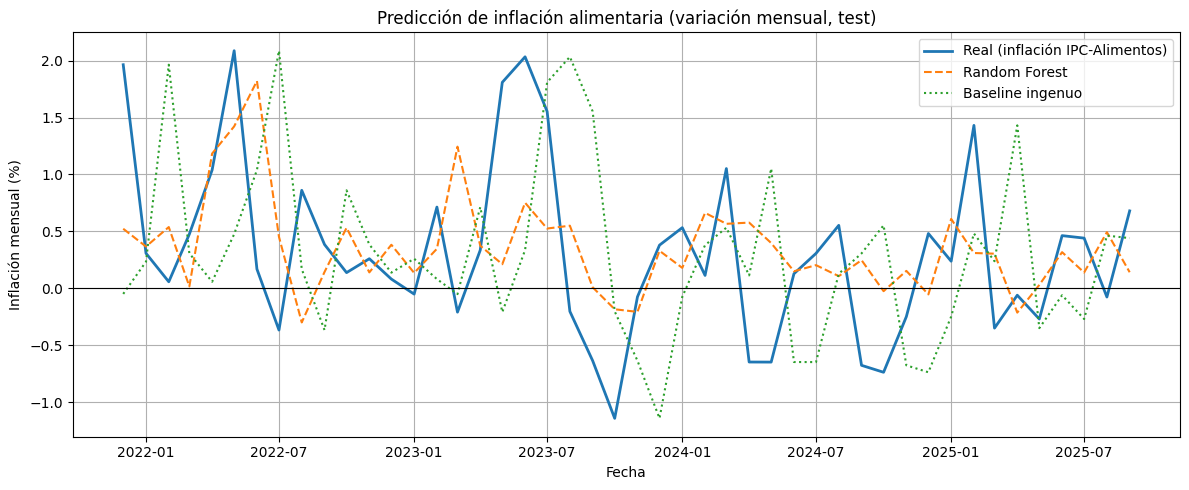

In [40]:
import matplotlib.pyplot as plt

test_plot = test.copy()
test_plot["y_real"] = y_test
test_plot["y_pred_rf"] = rf_test_pred
test_plot["y_pred_naive"] = naive_test_pred

plt.figure(figsize=(12,5))
plt.plot(test_plot.index, test_plot["y_real"], label="Real (inflación IPC-Alimentos)", linewidth=2)
plt.plot(test_plot.index, test_plot["y_pred_rf"], label="Random Forest", linestyle="--")
plt.plot(test_plot.index, test_plot["y_pred_naive"], label="Baseline ingenuo", linestyle=":")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Predicción de inflación alimentaria (variación mensual, test)")
plt.xlabel("Fecha")
plt.ylabel("Inflación mensual (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
